# Forecast Errors: A First Look

*Companion notebook to Workshop 1 of the seminar **Structural Change and Expectations in Macroeconomics and Finance** (University of Copenhagen, Autumn 2026).*

In Workshop 1 we derived what the rational expectations hypothesis (REH) predicts about forecast errors: they should be **unbiased** and **uncorrelated with anything known at the time of the forecast** — in the forecast-error regression $e_{t+1} = \alpha + \beta z_t + u_{t+1}$, REH predicts $\alpha = \beta = 0$.

This notebook confronts that prediction with real data: US professional forecasters' inflation forecasts. It reproduces every figure shown in class, and each step is a handful of lines of code.

**Everything here is a template.** Change a column, a sample, a horizon, a country — and you have the start of a seminar paper.

**How to run it:** locally with Python (needs only `pandas`, `numpy`, `matplotlib`, `statsmodels`, `scipy`), or in the cloud via Google Colab — no installation needed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

# House colors and a clean plotting style
BLUE, RED, TEAL, GREY = "#006BA2", "#DB444B", "#3EBCD2", "#758D99"
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.alpha": 0.35,
    "axes.titlelocation": "left", "axes.titlesize": 12, "font.size": 11,
})

## 1. The data

We use the **Survey of Professional Forecasters (SPF)**, the oldest quarterly survey of macroeconomic forecasts in the United States (running since 1968, maintained by the Federal Reserve Bank of Philadelphia). Each quarter, professional forecasters predict inflation and other variables several quarters ahead; we use the **mean forecast** across forecasters.

Details that matter (and that you should get right in your own paper):

- **Variable**: inflation in the GDP price deflator (the SPF's longest-running inflation series — not CPI).
- **Horizon**: one year ahead, measured as the *average quarterly* inflation rate over the next four quarters. `F_avg` is the forecast, `pi_avg` the realized value, `error_avg = pi_avg − F_avg` the forecast error.
- **Actuals are first-release data**: forecasters were predicting the economy as it was first measured, not as it looks after decades of revisions. Using today's revised data would stack the deck against them.
- **Timing**: a forecast dated quarter $t$ uses information available through quarter $t$. The **forecast revision** `revision_avg` is how much the forecasters changed their prediction of the *same* outcome between quarter $t-1$ and quarter $t$ — something they know at time $t$.

Sample: 1970Q2–2024Q2.

In [2]:
def load(name):
    try:  # running locally with the repo cloned
        df = pd.read_csv(f"../data/{name}", index_col="quarter")
    except FileNotFoundError:  # running on Colab: read straight from GitHub
        base = "https://raw.githubusercontent.com/mortentabor/structural-change-seminar/main/data/"
        df = pd.read_csv(base + name, index_col="quarter")
    df.index = pd.PeriodIndex(df.index, freq="Q")
    return df

fe = load("forecast_errors.csv")
inflation = load("inflation_quarterly.csv")
fe.tail(3)

,F_avg,pi_avg,error_avg,revision_avg,pi_lag,error_avg_h1,error_avg_h2,error_avg_h3,revision_avg_h1,revision_avg_h2,revision_avg_h3
quarter,,,,,,,,,,,
2023Q4,2.141275,2.360500,0.219225,-0.523275,1.4806,1.0144,0.57990,0.261633,-0.6273,-0.56745,-0.531367
2024Q1,2.558100,2.515650,-0.042450,0.403400,3.1213,-0.6106,-0.67340,-0.491333,0.7560,0.55865,0.445500
2024Q2,2.378950,2.439775,0.060825,-0.011950,2.2829,-0.5577,-0.36445,0.225800,-0.1785,-0.06725,-0.078867


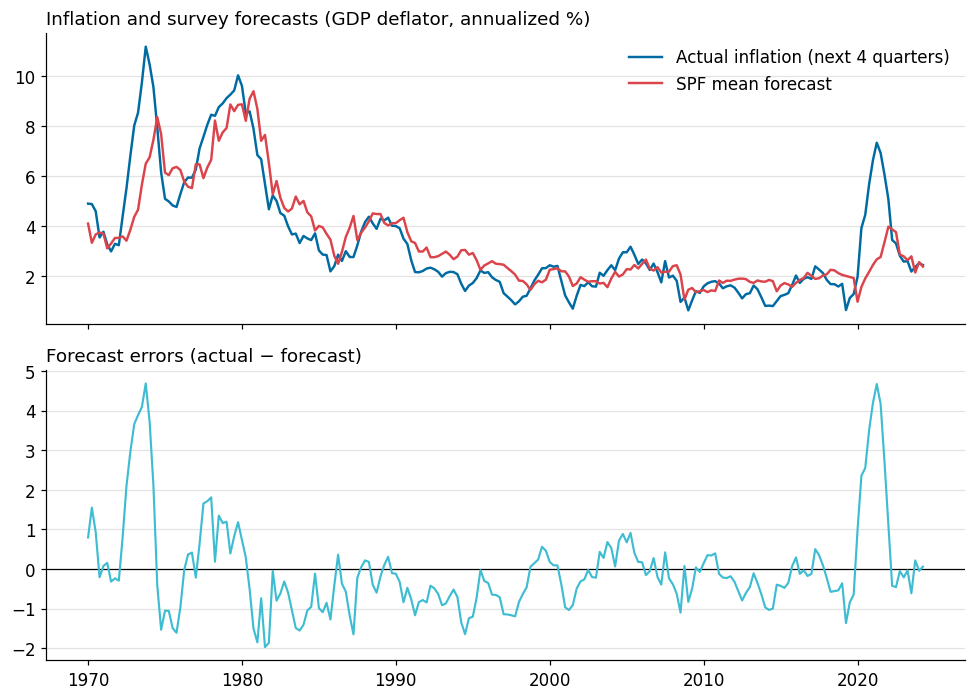

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)
x = fe.index.to_timestamp()

axes[0].plot(x, fe["pi_avg"], color=BLUE, lw=1.6, label="Actual inflation (next 4 quarters)")
axes[0].plot(x, fe["F_avg"], color=RED, lw=1.6, label="SPF mean forecast")
axes[0].set_title("Inflation and survey forecasts (GDP deflator, annualized %)")
axes[0].legend(frameon=False)

axes[1].axhline(0, color="black", lw=0.8)
axes[1].plot(x, fe["error_avg"], color=TEAL, lw=1.4)
axes[1].set_title("Forecast errors (actual − forecast)")

plt.tight_layout()
plt.show()

Look at the two panels before running any regression:

- Forecasts track inflation closely much of the time — these are serious forecasters.
- But the errors are not just noise: forecasters **under-predicted persistently through the 1970s inflation**, **over-predicted through the disinflation of the 1980s**, and **under-predicted again in 2021–22**.

Do those errors *look* unpredictable to you? That is exactly what REH claims they should be. Let's test it.

## 2. The forecast-error regression, full sample

From Workshop 1: under REH, forecast errors are uncorrelated with anything the forecasters knew at the time. We regress the error on the forecasters' **own forecast revision** — unquestionably known to them at time $t$:

$$e_{t+1} = \alpha + \beta \, \text{revision}_t + u_{t+1}, \qquad \text{REH: } \alpha = \beta = 0.$$

This is the regression made famous by Coibion and Gorodnichenko (2015). Because forecast horizons overlap across quarters, the errors are serially correlated by construction — so we use HAC (Newey–West) standard errors.

In [4]:
df = fe.dropna(subset=["error_avg", "revision_avg"])

y = df["error_avg"]
X = sm.add_constant(df["revision_avg"])
cg = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

print(f"Sample: {df.index.min()}–{df.index.max()}  (n = {int(cg.nobs)})")
print(cg.summary().tables[1])

Sample: 1970Q2–2024Q2  (n = 216)
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0247      0.127     -0.195      0.846      -0.273       0.224
revision_avg     1.1198      0.405      2.765      0.006       0.326       1.914


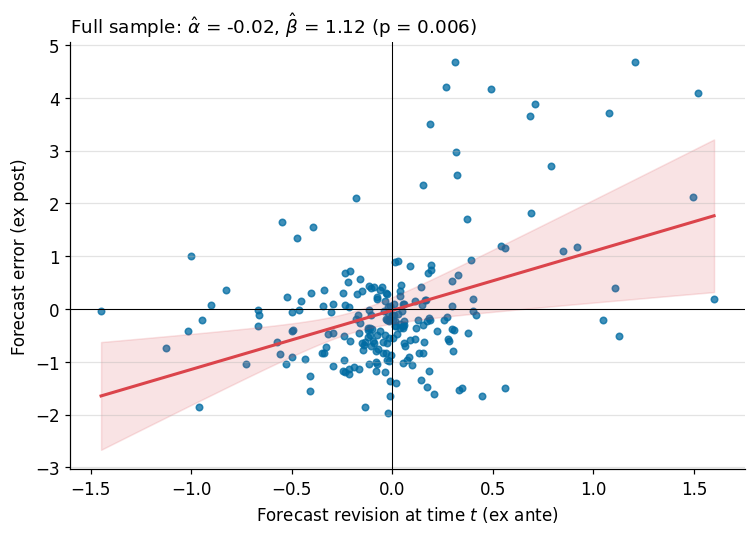

In [5]:
def scatter_fit(ax, d, color=RED):
    """Scatter error vs revision, add OLS fit line with a 95% HAC confidence band."""
    res = sm.OLS(d["error_avg"], sm.add_constant(d["revision_avg"])).fit(
        cov_type="HAC", cov_kwds={"maxlags": 4})
    ax.scatter(d["revision_avg"], d["error_avg"], s=18, color=BLUE, alpha=0.75)
    grid = np.linspace(d["revision_avg"].min(), d["revision_avg"].max(), 200)
    Xg = np.column_stack([np.ones_like(grid), grid])
    fit = Xg @ res.params.values
    se = np.sqrt(np.sum((Xg @ res.cov_params().values) * Xg, axis=1))
    tcrit = stats.t.ppf(0.975, res.df_resid)
    ax.plot(grid, fit, color=color, lw=2)
    ax.fill_between(grid, fit - tcrit * se, fit + tcrit * se, color=color, alpha=0.15)
    ax.axhline(0, color="black", lw=0.7)
    ax.axvline(0, color="black", lw=0.7)
    return res

fig, ax = plt.subplots(figsize=(7, 5))
res = scatter_fit(ax, df)
ax.set_xlabel("Forecast revision at time $t$ (ex ante)")
ax.set_ylabel("Forecast error (ex post)")
ax.set_title(
    f"Full sample: $\\hat\\alpha$ = {res.params.iloc[0]:.2f}, "
    f"$\\hat\\beta$ = {res.params.iloc[1]:.2f} (p = {res.pvalues.iloc[1]:.3f})")
plt.tight_layout()
plt.show()

**The result:** $\hat\beta \approx 1.1$, statistically significant. Forecast errors are *predictable from the forecasters' own revisions* — when forecasters revise upward, they subsequently tend to fall short anyway. Full-information REH (FIRE) predicts a flat line through zero. The data says otherwise. The intercept, by contrast, behaves: $\hat\alpha \approx 0$ and insignificantly different from zero — over the full sample, forecast errors show no bias on average.

And this is no quirk of one dataset. Since Mincer and Zarnowitz (1969), a huge empirical literature has estimated forecast-error regressions like this one — and FIRE's unpredictability prediction has been rejected for a wide range of macroeconomic and financial variables, across countries, surveys, and sample periods. The finding is extremely robust.

**So: what can we conclude based on these findings? Are professional forecasters not rational? What else could explain these findings?**

## 3. What could explain it?

The literature offers several accounts — each relaxes a different assumption behind the test. Each of these could be an entry point for a seminar paper:

- **Information rigidities** — forecasters are rational but update on sticky or noisy information, so revisions predict errors. *Coibion & Gorodnichenko (2015), "Information Rigidity and the Expectation Formation Process," AER.*
- **Overreaction / behavioral bias** — individual forecasters overreact to news (diagnostic expectations). *Bordalo, Gennaioli, Ma & Shleifer (2020), "Overreaction in Macroeconomic Expectations," AER.*
- **Learning about the long run** — forecasters rationally learn about slow-moving parameters, generating persistent errors along the way. *Farmer, Nakamura & Steinsson (2024), "Learning About the Long Run," JPE.*
- **Regime-switching FIRE** — forecasters are fully rational with full information, but the economy switches between recurring regimes; that alone makes forecast errors predictable within a sample. *Hajdini & Kurmann (2024), "Predictable Forecast Errors in Full-Information Rational Expectations Models with Regime Shifts," working paper.*
- **Unforeseeable structural change** — the inflation process itself changes in nonrepetitive ways; errors that look systematic ex post were not predictable ex ante. *Frydman & Tabor (2025), INET Center working papers 1–2.*

For a map of this literature, start with *Coibion, Gorodnichenko & Kamdar (2018), "The Formation of Expectations, Inflation, and the Phillips Curve," Journal of Economic Literature*, Sections 1–4.

But before reaching for any of these, notice what the regression above quietly assumed: **that $\alpha$ and $\beta$ are constant over the whole sample, 1970–2024.** Is that plausible? Let's look.

## 4. Is the relation itself stable?

The simplest check: split the sample into three economically distinct periods — the Great Inflation of the 1970s, the long Great Moderation (1980–2019), and the post-2020 inflation surge — and estimate the same regression in each.

In [6]:
SUBSAMPLES = {
    "1970s":            ("1970Q2", "1979Q4"),
    "Great Moderation": ("1980Q1", "2019Q4"),
    "Post-2020":        ("2020Q1", "2024Q2"),
}

rows = []
for name, (start, end) in SUBSAMPLES.items():
    d = df.loc[start:end]
    r = sm.OLS(d["error_avg"], sm.add_constant(d["revision_avg"])).fit(
        cov_type="HAC", cov_kwds={"maxlags": 4})
    rows.append({"sample": name,
                 "alpha": r.params.iloc[0], "se(alpha)": r.bse.iloc[0], "p(alpha)": r.pvalues.iloc[0],
                 "beta": r.params.iloc[1], "se(beta)": r.bse.iloc[1], "p(beta)": r.pvalues.iloc[1],
                 "n": int(r.nobs)})

pd.DataFrame(rows).round(3)

,sample,alpha,se(alpha),p(alpha),beta,se(beta),p(beta),n
0,1970s,0.527,0.352,0.134,1.166,0.634,0.066,38
1,Great Moderation,-0.402,0.086,0.000,0.073,0.144,0.609,160
2,Post-2020,1.188,0.701,0.090,1.198,0.537,0.026,18


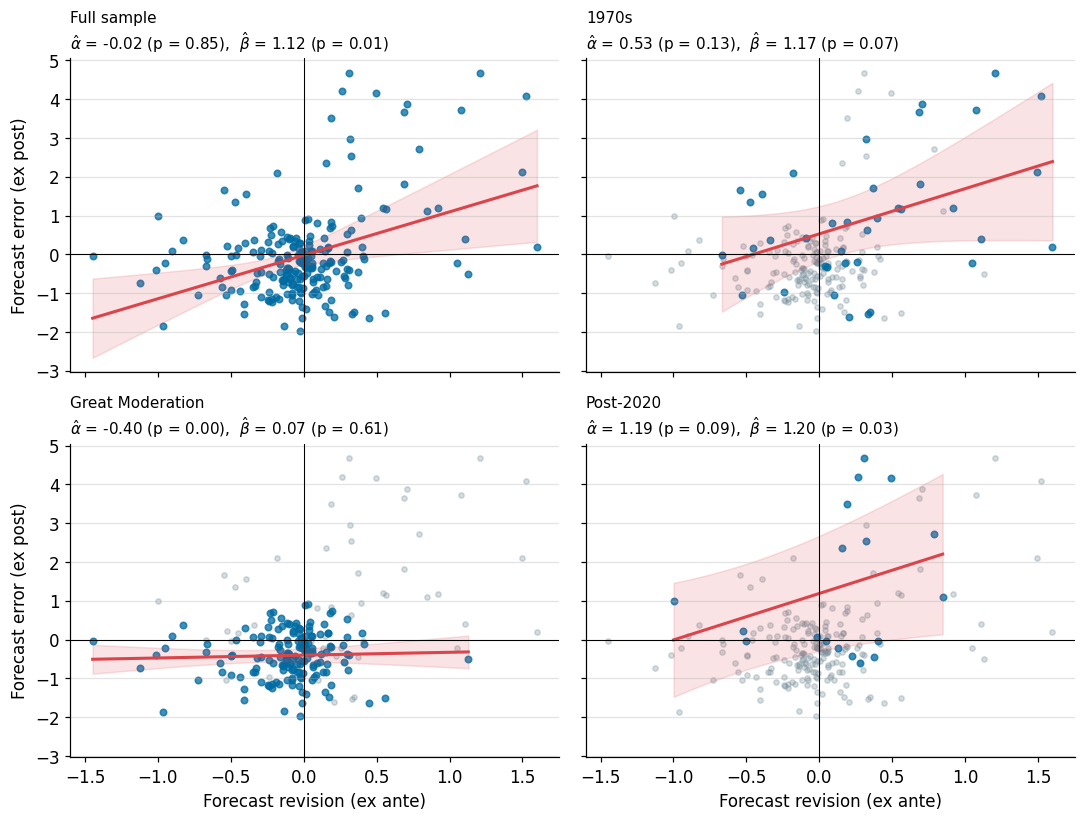

In [7]:
panels = [("Full sample", None)] + list(SUBSAMPLES.items())
ncols = 2
nrows = int(np.ceil(len(panels) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.8 * nrows), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for ax, (name, span) in zip(axes.flat, panels):
    d = df if span is None else df.loc[span[0]:span[1]]
    if span is not None:  # grey out observations from outside the subsample
        rest = df.drop(d.index)
        ax.scatter(rest["revision_avg"], rest["error_avg"], s=12, color=GREY, alpha=0.3)
    r = scatter_fit(ax, d)
    ax.set_title(f"{name}\n$\\hat\\alpha$ = {r.params.iloc[0]:.2f} (p = {r.pvalues.iloc[0]:.2f}),  "
                 f"$\\hat\\beta$ = {r.params.iloc[1]:.2f} (p = {r.pvalues.iloc[1]:.2f})", fontsize=10)

for ax in axes.flat[len(panels):]:  # hide any unused panel
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("Forecast revision (ex ante)")
for ax in axes[:, 0]:
    ax.set_ylabel("Forecast error (ex post)")
plt.tight_layout()
plt.show()

**The conclusion.** The "significant" full-sample relationship is not a stable feature of expectation formation:

- Across the **forty years of the Great Moderation**, $\hat\beta \approx 0$ — forecast errors were not predictable from revisions, just as REH says.
- The large $\hat\beta$ shows up only in the **two great inflationary episodes**: the 1970s and post-2020.
- But now look at $\hat\alpha$: insignificant over the full sample, yet **significantly negative during the Great Moderation**. Through the four stable decades, forecasters persistently *over*-predicted inflation — so even in the period where $\hat\beta \approx 0$, the forecast errors were **biased**, not unpredictable.

Both $\alpha$ and $\beta$ shift across periods, and the full-sample estimates are *averages over very different regimes*. That raises the questions this seminar lives on:

1. What does parameter instability do to the **test**? (If $\alpha$ and $\beta$ shift, what is the full-sample regression even estimating?)
2. What does it do to the **explanations** in Section 3? (An account of a constant $\beta > 0$ is answering the wrong question if $\beta$ is not constant.)
3. And what changed in those episodes — the forecasters, or the economy they were forecasting?

**But what is the problem with the subsample split itself?** Think about it before reading on: we chose the three periods ourselves.

The split dates are imposed by us — somewhat, but not completely, arbitrarily. The three periods correspond to well-known macroeconomic eras, so they are not pulled out of thin air. But the dates where not identified from the data, and we picked them knowing what the sample looks like. Different splits might tell a different story (try changing the subsample dates above and rerun the cells to see how the estimates change).

Sample splits are the simplest tool for detecting instability along with rolling window estimations, which, however, might be difficult to interpret. Formal tools — testing for breaks at *unknown* dates (Bai–Perron), regime-switching models, etc. — **identify the break dates from the data**. They are the topic of **Workshop 3**.

## 5. From finding to question

You have now seen that the relation is not stable. **That, by itself, is not yet a research question.** "Is X stable? — No" is a finding, not a paper. The interesting paper starts with what you build *on top of* the finding. Four types of questions you can build:

1. **Timing / episodes** — do the shifts line up with identifiable economic history? (Are the systematic errors concentrated in the great inflationary episodes — the 1970s, COVID?)
2. **Source / mechanism** — *what* changed: the forecasters' behavior, or the inflation process they were forecasting?
3. **Interpretation / inference** — what does instability do to the tools? If $\alpha$ and $\beta$ shift, can the forecast-error regression test rational expectations at all? What is the full-sample estimate even measuring?
4. **Consequences / practice** — what does it mean for those who *use* these forecasts (central banks, markets) that the errors turn systematic exactly in the turbulent episodes?

**The "This paper…" exercise.** A research question is specific when you can state what the paper *delivers*. Compare (on a different relation):

> *Weak:* "This paper examines whether Okun's law is stable."
>
> *Strong:* "This paper shows that Okun's law held in every US recession since 1960 except 2020, and asks what made the COVID labor market different."

The strong version states a deliverable and why it is interesting — even before the analysis exists.

**Your task:** write one or two **"This paper…"** sentences for this exhibit. Be specific: what does your paper show, ask, or deliver?

## 6. What you could vary

This notebook is not just for reading — **edit it and rerun it.** A notebook runs in cells: click a code cell, change something, and press **Shift+Enter** (or the Run button) to re-execute it; then rerun any later cells that depend on it. If you lose track of what has been run, simply run everything from the top — in Colab: *Runtime → Run all*; in Jupyter: *Run → Run All Cells*. Nothing can break: the data is reloaded from the file every time, so you can always start over.

**A worked example — change the subsample split.** Suppose you suspect the Great Moderation was not one stable period, and you want to split it at the financial crisis. Go to the first code cell in Section 4 and change

```python
SUBSAMPLES = {
    "1970s":            ("1970Q2", "1979Q4"),
    "Great Moderation": ("1980Q1", "2019Q4"),
    "Post-2020":        ("2020Q1", "2024Q2"),
}
```

to, for example,

```python
SUBSAMPLES = {
    "1970s":             ("1970Q2", "1979Q4"),
    "Before the crisis": ("1980Q1", "2007Q4"),
    "After the crisis":  ("2008Q1", "2019Q4"),
    "Post-2020":         ("2020Q1", "2024Q2"),
}
```

Press Shift+Enter on that cell — the estimates table is recomputed with your periods. Then rerun the figure cell below it — the grid of scatterplots grows automatically to fit however many subsamples you define. That is the whole workflow: **change a line, rerun, look.**

Every variation below works the same way — and several could be the seed of a seminar paper:

- **The horizon**: the data includes errors and revisions at 1–3 quarters ahead (`error_avg_h1`, `revision_avg_h1`, …). Does predictability depend on how far ahead forecasters look?
- **The regressor**: replace the revision with **lagged inflation** (`pi_lag`) — anything known at time $t$ is a valid test. Do different regressors tell the same story?
- **The specification**: regress the *actual* on the *forecast* ($\pi_{t+1} = \alpha + \beta F_t + u$; REH: $\alpha=0, \beta=1$) — the classic Mincer–Zarnowitz test.
- **The sample splits**: are the three periods the right cut? Try your own (see the worked example above) — or wait for Workshop 3's tools that let the data choose the break dates.
- **The country / the survey**: the ECB SPF, Consensus Economics, or household surveys (Michigan) let you ask the same questions elsewhere.

### Data dictionary (`data/forecast_errors.csv`)

| Column | Meaning |
|---|---|
| `F_avg` | SPF mean forecast of average quarterly inflation over the next 4 quarters |
| `pi_avg` | Realized average quarterly inflation over those 4 quarters (first release) |
| `error_avg` | Forecast error: `pi_avg − F_avg` |
| `revision_avg` | Revision of the forecast of the same outcome since last quarter |
| `pi_lag` | Inflation over the four quarters ending at time $t$ (known at $t$) |
| `*_h1, *_h2, *_h3` | Same objects at horizons of 1–3 quarters |

*Data: Survey of Professional Forecasters and real-time GDP-deflator vintages, Federal Reserve Bank of Philadelphia. Dataset construction follows Frydman & Tabor (2025).*

## References

- Bordalo, P., Gennaioli, N., Ma, Y., and Shleifer, A. (2020). "Overreaction in Macroeconomic Expectations." *American Economic Review*, 110(9), 2748–2782.
- Coibion, O., and Gorodnichenko, Y. (2015). "Information Rigidity and the Expectation Formation Process: A Simple Framework and New Facts." *American Economic Review*, 105(8), 2644–2678.
- Coibion, O., Gorodnichenko, Y., and Kamdar, R. (2018). "The Formation of Expectations, Inflation, and the Phillips Curve." *Journal of Economic Literature*, 56(4), 1447–1491.
- Farmer, L. E., Nakamura, E., and Steinsson, J. (2024). "Learning About the Long Run." *Journal of Political Economy*, 132(10).
- Frydman, R., and Tabor, M. N. (2025). "Rational Expectations of Inflation Undergoing Unforeseeable Change." INET Center on Knightian Uncertainty, Working Paper No. 1.
- Frydman, R., and Tabor, M. N. (2025). "Unforeseeable Change in Rational Participants' Inflation Expectations: Evidence from Forecast-Error Regressions." INET Center on Knightian Uncertainty, Working Paper No. 2.
- Hajdini, I., and Kurmann, A. (2024). "Predictable Forecast Errors in Full-Information Rational Expectations Models with Regime Shifts." Working paper.
- Mincer, J., and Zarnowitz, V. (1969). "The Evaluation of Economic Forecasts." In J. Mincer (ed.), *Economic Forecasts and Expectations: Analyses of Forecasting Behavior and Performance*. New York: National Bureau of Economic Research.